$$\frac{\partial^2 u}{\partial t^2} = \frac{\partial^2 u}{\partial x^2} \quad ; -1 \le x \le 1$$

Initial Conditions
$$u(x, 0) = f(x) = \sin(\pi x),$$

$$u_t(x, 0) = g(x) = 0$$

with the boundary conditions

$$u(-1,t) = u(1,t) = 0.$$

The analytical solution is given in $[17]$ as

$$u(x,t) = \frac{1}{2}(\sin(\pi(x+t)) + \sin(\pi(x-t))).$$

In [239]:
import numpy as np
import matplotlib.pyplot as plt
from SG_solver import rbf_matrix, second_divided_difference, d2_L_W2
# from SPD_solver import solve_spd
from fractal_SG_solver_new import  build_fractal_second_derivative
# , d2_fractal_phi_pointwise, d2_fractal_psi, d2_fractal_L_W2 
from SG_solver import d2_phi, varphi, error_function 

In [240]:
# Paper Example 1 parameters.
a = -1.0
b = 1.0
#######################
K = 8
s = 0.8
c = 0.027 
################
h = 0.01
tau = 0.01
################
T = 0.01
###################


In [241]:
# Fractal parameters
f_alpha = 1/800
n_points = 2000
n_iter = 100

$$x_i = a + \frac{i(b-a)}{n}, \quad i = 0, \ldots, n,$$

and $N = \frac{n}{K}$ , where K is a positive integer. The choice of
the interpolation centers $\{x_{k_j}\}_{j=1}^N$ as follows

$$x_{k_1} = x_1, \quad x_{k_N} = x_{n-1},$$

$$x_{k_j} = a + \frac{(j-1)(b-a)}{N}, \quad j = 2, \dots, N-1.$$

In [242]:
n = (b - a) / h

if n != int(n):
    raise ValueError("h must divide b-a exactly.")

n = int(n)

if n % K != 0:
    raise ValueError("n must be divisible by K because the paper defines N = n / K.")

N = n // K
Nt = int(round(T / tau))
# Nt = 0

x = np.linspace(a, b, n + 1)

# Interpolation center indices k_j, j = 1,...,N
k_idx = np.concatenate(([1], K * np.arange(1, N - 1), [n - 1])).astype(int)

xk = x[k_idx]
xkj = []
for j in range(1, N+1):
    if j == 1:
        value = float(x[1])
        xkj.append(value)

    elif 1 < j < N:
        value = a + ((j - 1) * (b - a)) / N
        xkj.append(value)
    elif j == N:
        value = float(x[n - 1])
        xkj.append(value)


# print(x)
# print(xk)
# print(xkj)

The analytical solution is given in $[17]$ as

$$u(x,t) = \frac{1}{2}(\sin(\pi(x+t)) + \sin(\pi(x-t))).$$

In [243]:
def exact_u(x, t):
    return 0.5 * (np.sin(np.pi * (x + t)) + np.sin(np.pi * (x - t)))
    # equivalently: np.sin(np.pi * x) * np.cos(np.pi * t)

At $t=0$, 
$$u(x,0) = \sin(\pi x).$$

In [244]:
# Storage for time and space levels
# U[d, i] ≈ u(x_i, d*tau), d=0,...,Nt

U = np.zeros((Nt + 2, len(x)))
print(np.shape(U))

# Initial condition at t=0
U[0, :] = exact_u(x, 0)

(3, 201)


The boundary conditions

$$u(-1,t) = u(1,t) = 0.$$

In [245]:
U[0, 0]  = 0.0
U[0, -1] = 0.0

$$
\sum_{j=1}^{N} \alpha_j \varphi(|x_{k_i}-x_{k_j}|) =
\frac{2u_{k_i+1}^{n}}{(x_{k_i+1}-x_{k_i})(x_{k_i+1}-x_{k_i-1})}
+ \frac{2u_{k_i-1}^{n}}{(x_{k_i}-x_{k_i-1})(x_{k_i+1}-x_{k_i-1})}
- \frac{2u_{k_i}^{n}}{(x_{k_i}-x_{k_i-1})(x_{k_i+1}-x_{k_i})}.
\tag{19}$$

The right side is the same three-point second divided-difference formula from Eq. 15, and applied at the current time-level values $u_n$.
$$ \alpha_m = \sum_{i=1}^{N}\left[A^{-1}\right]_{mi}\left(\frac{2u_{k_i+1}^{n}}{(x_{k_i+1}-x_{k_i})(x_{k_i+1}-x_{k_i-1})} + \frac{2u_{k_i-1}^{n}}{(x_{k_i}-x_{k_i-1})(x_{k_i+1}-x_{k_i-1})} - \frac{2u_{k_i}^{n}}{(x_{k_i}-x_{k_i-1})(x_{k_i+1}-x_{k_i})} \right),\\ \quad m=1,\ldots,N,$$
$$A_{ij}=\varphi(|x_{k_i}-x_{k_j}|)$$

In [246]:
# Build approximation of u_xx at t=0
A0 = rbf_matrix(xk, s)
rhs0 = []
for kj in k_idx:
    rhs0.append(second_divided_difference(x, U[0, :], kj))
rhs0 = np.asarray(rhs0)

alpha0 = np.linalg.solve(A0, rhs0)

# print("alpha0:", alpha0)

$$u_{k}^{n+1} = 2u_{k}^{n} - u_{k}^{n-1} + \tau^{2} \left[ \sum_{j=1}^{N} \alpha_{j} \varphi(x_{k} - x_{k_{j}}) + \sum_{i=0}^{n} \left( u_{i}^{n} - \sum_{j=1}^{N} \alpha_{j} \sqrt{s^{2} + (x_{i} - x_{k_{j}})^{2}} \right) \psi_{i}''(x_{k}) \right], \tag{18}$$
$$u_{k}^{n+1} = 2u_{k}^{n} - u_{k}^{n-1} + \tau^{2}*\left(L_{w_{2}}u_{k}^{n}\right)''$$

Given initial condition: 
$$u_t(x, 0) = g(x) = 0$$
Using Central Difference:
$$u_{k}^{-1}= u_{k}^{1}$$
We have
$$u_{k}^{1} = u_{k}^{0} + \frac{1}{2}*\tau^{2}*\left(L_{w_{2}}u_{k}^{n}\right)''$$


In [247]:
# for 1st time step
uxx0 = np.zeros(len(x))
for i in range(len(x)):
    uxx0[i] = d2_L_W2(i, x, U[0, :], xk, alpha0, s, c)
   
# Since g(x)=0
U[1, :] = U[0, :] + 0.5 * tau**2 * uxx0
U[1, 0]  = 0.0
U[1, -1] = 0.0

In [248]:
# Time stepping:
# u_k^{n+1} = 2u_k^n - u_k^{n-1} + tau^2 * (L_w2 u_k^d)''
# using d instead of n for time level index to avoid confusion with spatial index k.
count = 0
for d in range(1, Nt + 1):
    A = rbf_matrix(xk, s)
    rhs_d = np.asarray([second_divided_difference(x, U[d], kj) for kj in k_idx])
    alpha1 = np.linalg.solve(A, rhs_d)

    uxx = np.zeros(len(x))
    for i in range( len(x)):
        uxx[i] = d2_L_W2(i, x, U[d], xk, alpha1, s, c)

    U[d + 1, :] = 2.0 * U[d, :] - U[d - 1, :] + tau**2 * uxx

    # Dirichlet boundary conditions
    U[d + 1, 0] = 0.0
    U[d + 1, -1] = 0.0
    count += 1

In [249]:
fractal_dd = build_fractal_second_derivative(x, c, f_alpha, n_points, n_iter)


def d2_fractal_phi_pointwise(z, fractal_dd):
    return np.interp(z, fractal_dd["partition"], fractal_dd["values"])

def d2_fractal_psi(a, j, x, fractal_dd):
    """Second derivative of the fractal basis function psi_j."""

    n = len(x) - 1

    if j == 0:
        return (
            d2_fractal_phi_pointwise(a - x[1], fractal_dd)
            / (2 * (x[1] - x[0]))
        )

    if j == 1:
        return (
            (
                d2_fractal_phi_pointwise(a - x[2], fractal_dd)
                - d2_fractal_phi_pointwise(a - x[1], fractal_dd)
            )
            / (2 * (x[2] - x[1]))
            - d2_fractal_phi_pointwise(a - x[1], fractal_dd)
            / (2 * (x[1] - x[0]))
        )

    if j == n - 1:
        return (
            -d2_fractal_phi_pointwise(a - x[n - 1], fractal_dd)
            / (2 * (x[n] - x[n - 1]))
            - (
                d2_fractal_phi_pointwise(a - x[n - 1], fractal_dd)
                - d2_fractal_phi_pointwise(a - x[n - 2], fractal_dd)
            )
            / (2 * (x[n - 1] - x[n - 2]))
        )

    if j == n:
        return (
            d2_fractal_phi_pointwise(a - x[n - 1], fractal_dd)
            / (2 * (x[n] - x[n - 1]))
        )

    return (
        (
            d2_fractal_phi_pointwise(a - x[j + 1], fractal_dd)
            - d2_fractal_phi_pointwise(a - x[j], fractal_dd)
        )
        / (2 * (x[j + 1] - x[j]))
        - (
            d2_fractal_phi_pointwise(a - x[j], fractal_dd)
            - d2_fractal_phi_pointwise(a - x[j - 1], fractal_dd)
        )
        / (2 * (x[j] - x[j - 1]))
    )


def d2_fractal_L_W2(i, x, f, xk, alpha, s, fractal_dd):
    #               i, x, f, xk, alpha, s, c
    xx = x[i]

    rbf_part = 0.0
    for j in range(len(alpha)):
        rbf_part += alpha[j] * varphi(xx - xk[j], s)

    e_vals = np.zeros(len(x))
    for p in range(len(x)):
        e_vals[p] = error_function(p, x, f, xk, alpha, s)

    ld_part = 0.0
    for p in range(len(x)):
        ld_part += e_vals[p] * d2_fractal_psi(xx, p, x, fractal_dd)

    return rbf_part + ld_part

In [250]:
# Initial condition at t=0
f_U = np.zeros((Nt + 2, len(x)))
print(np.shape(f_U))
f_U[0, :] = exact_u(x, T)

f_U[0, 0]  = 0.0
f_U[0, -1] = 0.0

f_uxx0 = np.zeros(len(x))
for i in range(len(x)):
    # uxx0[i] = d2_L_W2(i, x, U[0, :], xk, alpha0, s, c)
    f_uxx0[i] = d2_fractal_L_W2(i, x, f_U[0, :], xk, alpha0, s, fractal_dd)

# Since g(x)=0
f_U[1, :] = f_U[0, :] + 0.5 * tau**2 * f_uxx0
f_U[1, 0]  = 0.0
f_U[1, -1] = 0.0

(3, 201)


In [251]:
# Time stepping:
# u_k^{n+1} = 2u_k^n - u_k^{n-1} + tau^2 * (L_w2 u_k^d)''
# using d instead of n for time level index to avoid confusion with spatial index k.
f_count = 0
for d in range(1, Nt + 1):
    A = rbf_matrix(xk, s)
    rhs_d = np.asarray([second_divided_difference(x, f_U[d], kj) for kj in k_idx])
    alpha2 = np.linalg.solve(A, rhs_d)

    f_uxx = np.zeros(len(x))
    for i in range( len(x)):
        f_uxx[i] = d2_fractal_L_W2(i, x, f_U[d], xk, alpha2, s, fractal_dd)

    f_U[d + 1, :] = 2.0 * f_U[d, :] - f_U[d - 1, :] + tau**2 * f_uxx

    # Dirichlet boundary conditions
    f_U[d + 1, 0] = 0.0
    f_U[d + 1, -1] = 0.0
    f_count += 1

/tmp/ipykernel_29036/3653584469.py:74: RuntimeWarning: overflow encountered in scalar multiply
  ld_part += e_vals[p] * d2_fractal_psi(xx, p, x, fractal_dd)
/tmp/ipykernel_29036/3653584469.py:74: RuntimeWarning: invalid value encountered in scalar add
  ld_part += e_vals[p] * d2_fractal_psi(xx, p, x, fractal_dd)


In [252]:

# Final solution and error at time T

u_num = U[Nt + 1, :]
f_u_num = f_U[Nt + 1, :]
u_ex = exact_u(x, T )  # Exact solution at T+tau because of the central difference initialization)

err = -(u_ex - u_num)
f_err = -(u_ex - f_u_num)

abs_err = np.abs(err)
f_abs_err = np.abs(f_err)

Linf = np.max(abs_err)
f_Linf = np.max(f_abs_err)

RMS = np.sqrt(np.mean(abs_err**2))
f_RMS = np.sqrt(np.mean(f_abs_err**2))

Linf_difference = np.abs(Linf - f_Linf)
RMS_difference = np.abs(RMS - f_RMS)
# print(u_num)
print("Time steps =", count)
print("Fractal Time steps =", f_count)
print("n =", n)
print("N =", N)
print("Nt =", Nt)
print("Linf error =", Linf)
print("f_Linf error =", f_Linf)
print("RMS error  =", RMS)
print("f_RMS error  =", f_RMS)
print("Linf difference =", Linf_difference)
print("RMS difference =", RMS_difference)

Time steps = 1
Fractal Time steps = 1
n = 200
N = 25
Nt = 1
Linf error = 0.0014799928233966142
f_Linf error = nan
RMS error  = 0.001043906417703379
f_RMS error  = nan
Linf difference = nan
RMS difference = nan


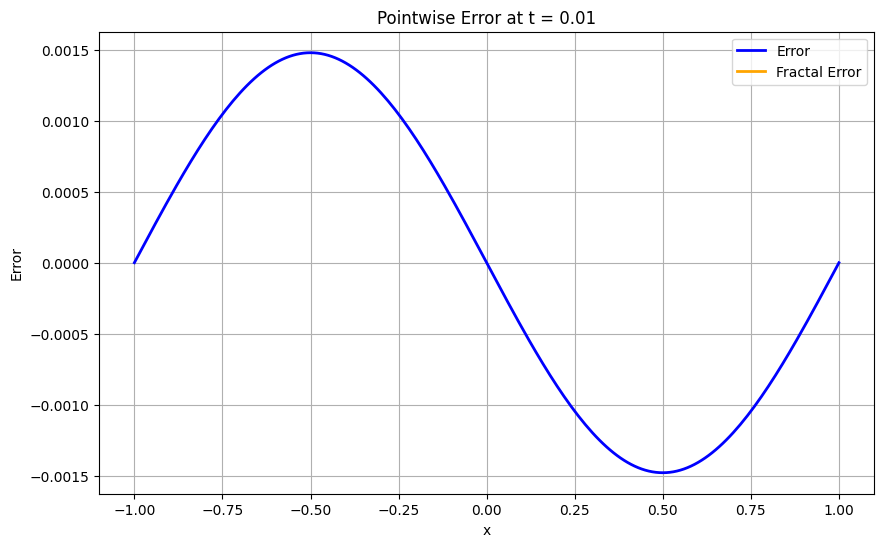

In [253]:
plt.figure(figsize=(10, 6))
plt.plot(x, err, label="Error", color="blue", linewidth=2)
plt.plot(x, f_err, label="Fractal Error", color="orange", linewidth=2)
plt.xlabel("x")
plt.ylabel("Error")
plt.title(f"Pointwise Error at t = {T}")
plt.grid(True)
plt.legend()
plt.show()